# Домашнее задание: градиентный бустинг

**Задача** — дополнить приведенную на лекции реализацию градиентного бустинга новым функционалом.

Необходимые функции:

 - В библиотечных реализациях есть параметр subsample (от 0 до 1), позволяющий обучать новое дерево не на всех объектах X, а на случайной подвыборке размера subsample. Добавьте его в свой класс.
Введенная таким образом случайность, снижает дисперсию ансамбля и предотвращает переобучение, делая деревья более разнообразными.

 - Согласно той же логике можно использовать и что-то похожее на метод случайных подпространств (вспомните лекцию про случайный лес) для обучения деревьев. Добавьте параметр colsample_bytree (тоже от 0 до 1). При обучении каждого базового дерева нужно давать ему доступ не ко всем признакам матрицы X, а только к случайной доле.

 - Добавьте свойство feature_importances_, которое возвращает массив с оценкой важности каждого признака. **Hint:** Как поскольку внутри используются DecisionTreeRegressor из sklearn, у каждого дерева уже есть атрибут feature_importances_. Нужно просто усреднить эти векторы по всем деревьям в ансамбле self.trees (с учетом learning rate).

  - Добавьте нативную поддержку категориальных признаков. 

Для желающих:

Реализуйте класс GBMClassifier, чтобы ваш бустинг мог решать не только задачу регрессии. Если сделаете рабочий классификатор, предыдущие пункты можно не выполнять.

В качестве доказательства правильности своей реализации сравните результаты обучения вашего бустинга с результатами библиотечного алгоритма на каком-либо датасете. Результаты не обязаны в точности совпадать, допустимым является отклонение вниз на 0.05 по метрике R^2. 

In [14]:
!pip install catboost

In [15]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [16]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


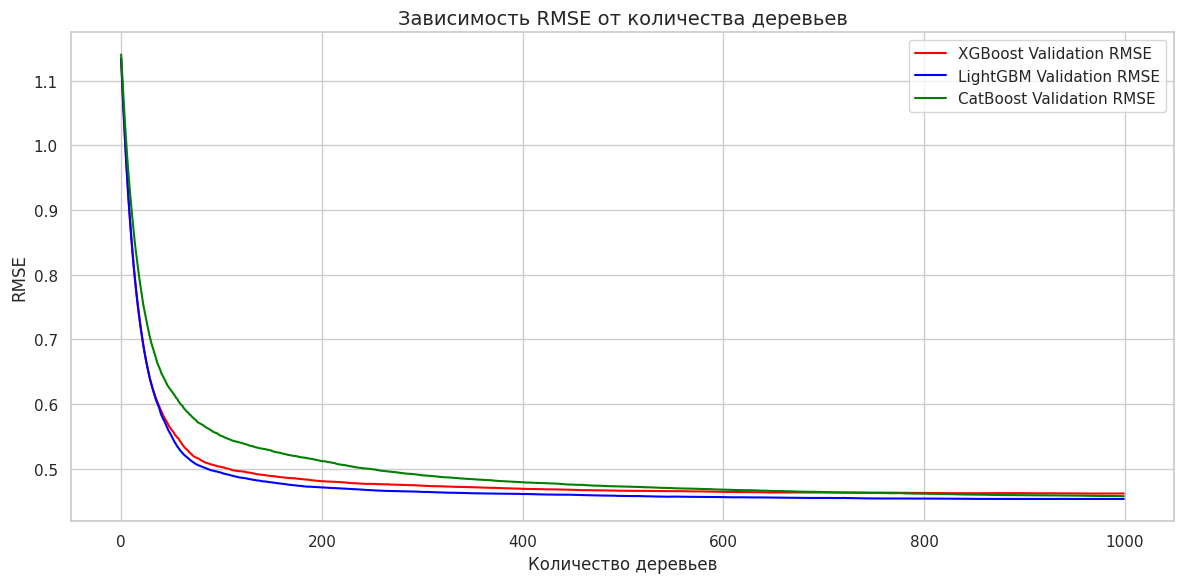

In [ ]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
SELECTED_N_ESTIMATORS = 400

In [ ]:
class MyBoost:
  def __init__(self, n=SELECTED_N_ESTIMATORS, lr=0.04, depth=7, seed=42, subsample = 0.8) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.subsample = subsample
      self.trees = []

  def fit(self, X, y):
    self.initial_leaf = y.mean()
    self.feature_importances_dict = {col: 0.0 for col in X.columns}
    predictions = np.zeros(len(y)) + self.initial_leaf

    for i in range(self.n):
      antigrad = y - predictions
      tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse", max_features=self.subsample)
      X_subsample, X_other, y_subsample, y_other = train_test_split(X, antigrad, test_size=0.3, random_state=i)
      tree.fit(X_subsample, y_subsample)
      self.trees.append(tree)
      
      predictions += tree.predict(X) * self.lr
      
      local_feature_importances = tree.feature_importances_
      for col, feature in zip(X_subsample.columns, local_feature_importances):
        self.feature_importances_dict[col] += feature
    
    for col in self.feature_importances_dict:
      self.feature_importances_dict[col] /= self.n

    self.feature_importances_ = np.array([self.feature_importances_dict[col] for col in X.columns])
    if(self.feature_importances_.sum() != 0):
      self.feature_importances_ /= self.feature_importances_.sum()
        
  def predict(self, samples):
    predictions = np.zeros(len(samples)) + self.initial_leaf
    for i in range(self.n):
      predictions += self.lr * self.trees[i].predict(samples)
    return predictions


In [20]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[7, 9],
    'subsample': [0.3, 0.8]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.3, 0.8]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [7, 9],
    'subsample':[0.5, 0.8]
}

grid_mb = {
    'lr':[0.05, 0.1],
    'depth':[7, 9],
    'subsample':[0.5, 0.8]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        elif model_name == 'CatBoost':
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)
        else:
            model = MyBoost(**params, seed=42)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)
best_params_dict['MyBoost'] = simple_grid_search('MyBoost', grid_mb)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4609
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 9, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.3}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4550
Лучшие параметры: {'depth': 9, 'learning_rate': 0.1, 'subsample': 0.8}

--- Запуск Grid Search для MyBoost ---
Лучший Validation RMSE: 0.4617
Лучшие параметры: {'depth': 7, 'lr': 0.05, 'subsample': 0.5}



In [64]:
results = []
features = []

names = ['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]

for name in names:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost(n=SELECTED_N_ESTIMATORS, seed=42, **params)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)
    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })
    raw_values = model.feature_importances_
    features.append(raw_values / raw_values.sum())

df_results = pd.DataFrame(results)
df_features = pd.DataFrame(features, columns=X.columns, index=names, dtype="float64")
display(df_results)
display(df_features)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,4.109,0.2898,0.4501,0.8454
1,LightGBM,0.604,0.2862,0.4379,0.8537
2,CatBoost,3.442,0.2901,0.4441,0.8495
3,MyBoost,10.865,0.2970,0.4517,0.8443


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
XGBoost,0.372691,0.066367,0.050718,0.034259,0.036774,0.166825,0.134263,0.138104
LightGBM,0.125583,0.091333,0.110417,0.094750,0.107583,0.138083,0.168000,0.164250
CatBoost,0.300087,0.065882,0.043636,0.028627,0.029113,0.125329,0.211854,0.195473
MyBoost,0.180455,0.074253,0.122021,0.088732,0.083185,0.125484,0.165042,0.160828


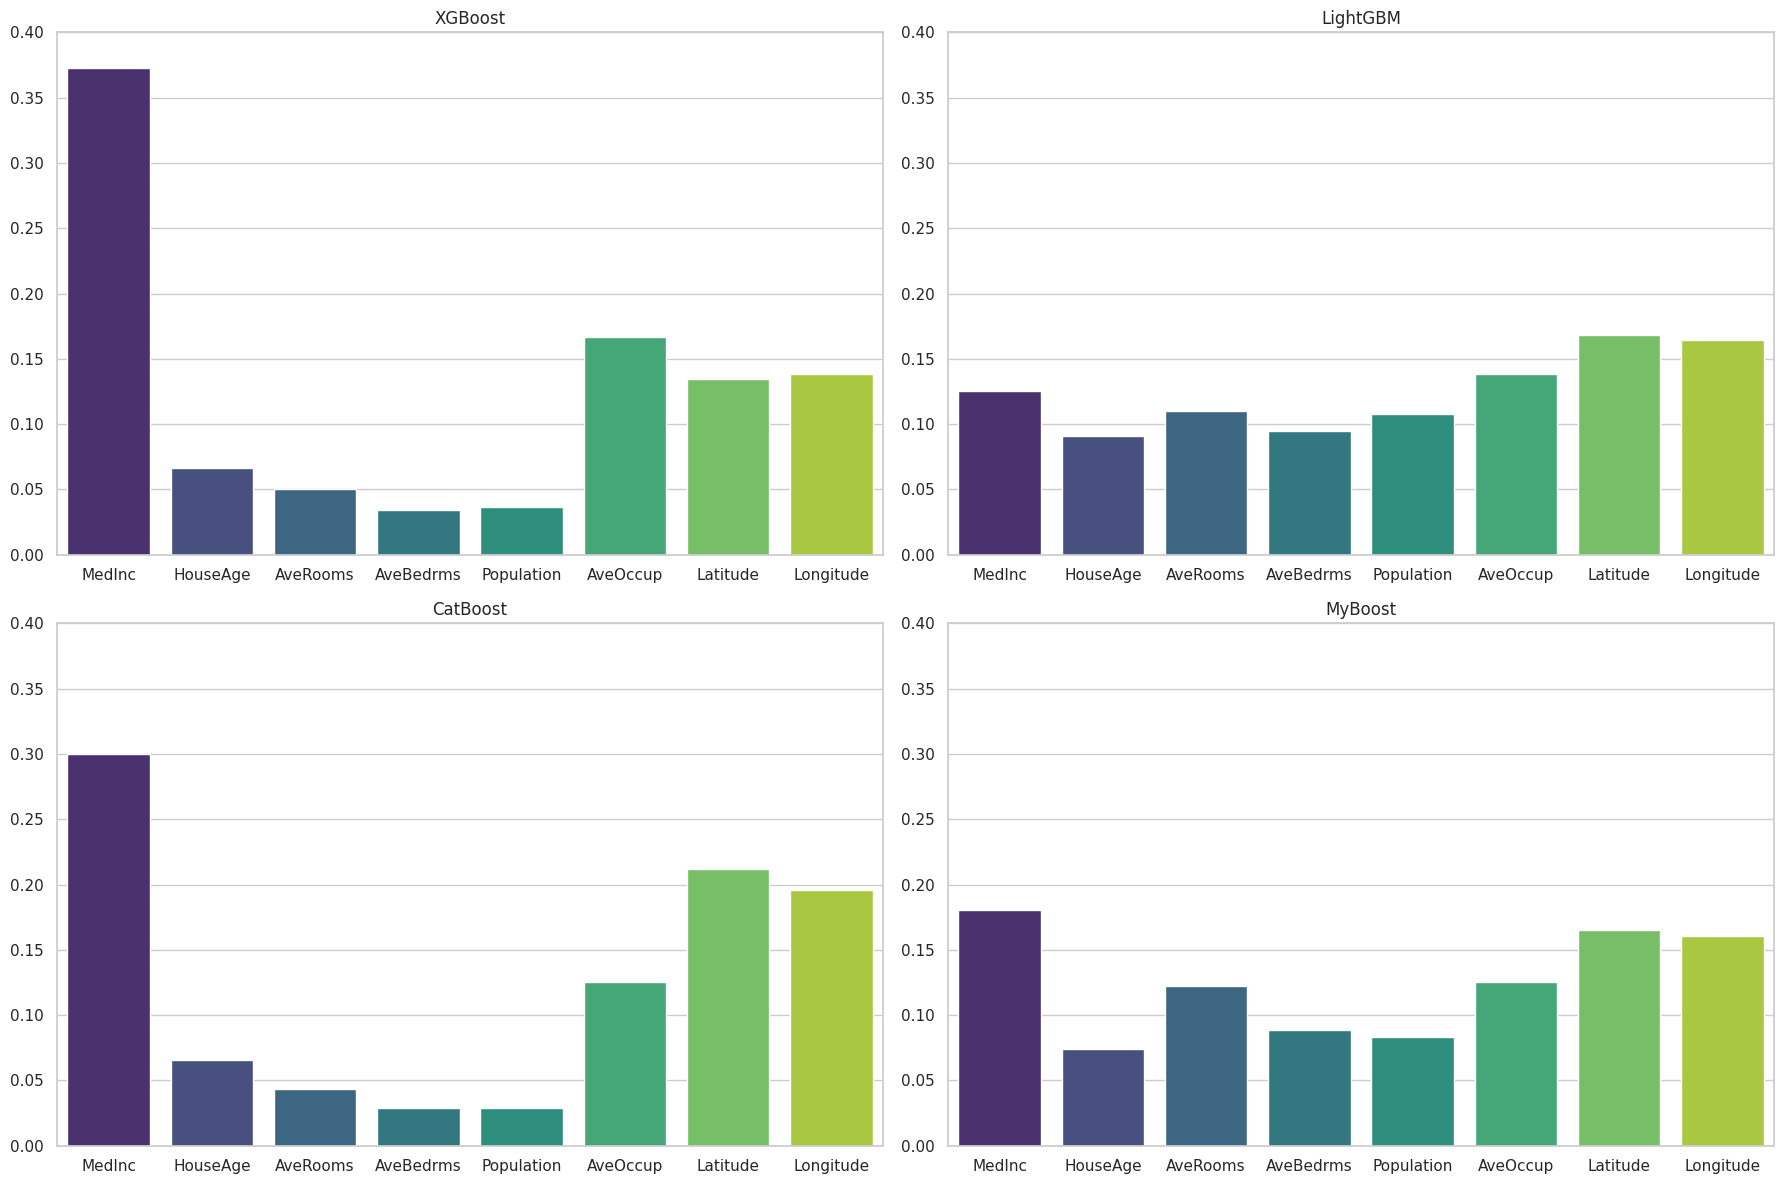

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize = (18, 12))
axes = axes.flatten()
for i in range(4):
    sns.barplot(y=df_features.values[i], x=X.columns, ax=axes[i], hue=X.columns, palette="viridis")
    axes[i].set_ylim(0,0.4)
    axes[i].set_title(names[i])
    axes[i].set_xlabel(None)  
plt.tight_layout()
plt.show()